# Simulating Daily CPI Loads into DuckDB

This notebook simulates running the CPI loading pipeline every day over a date range and compares the three loading methods:

- `append`
- `trunc`
- `inc`

It evaluates two things:

1. **Consistency**: do all methods produce the same final current-state data?
2. **Speed**: how long does each method take over the same set of daily runs?


## 1. Imports and setup


In [1]:
from pathlib import Path
import sys
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the project root is on the Python path when the notebook runs from /notebooks
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.cpi_pipeline import (
    DB_PATH,
    get_latest_data,
    init_db,
    load_method,
    reset_tables,
    simulate_daily_runs,
    compare_final_state,
)

print("Project root:", project_root)
print("Database path:", DB_PATH)


Project root: /Users/dl/Desktop/Python/26spring-project/-Xingyi-Wang---Aileen--api/lab8_hard
Database path: /Users/dl/Desktop/Python/26spring-project/-Xingyi-Wang---Aileen--api/lab8_hard/cpi.duckdb


## 2. Quick check of `get_latest_data()`

This confirms that the source-access function returns only the required two columns.


In [2]:
sample_df = get_latest_data("2004-01-15")
sample_df.head()


,obs_date,cpi
0,1947-01-01,21.5
1,1947-02-01,21.6
2,1947-03-01,22.0
3,1947-04-01,22.0
4,1947-05-01,22.0


In [3]:
sample_df.columns.tolist(), sample_df.shape


(['obs_date', 'cpi'], (684, 2))

## 3. Initialize the database


In [5]:
init_db()
print("Database initialized.")


Database initialized.


## 4. Manual spot-check for each loading method


In [6]:
# Reset tables before manual tests
reset_tables()

# Append
load_method("append", "2004-01-15")
load_method("append", "2004-02-15")

# Trunc
load_method("trunc", "2004-01-15")
load_method("trunc", "2004-02-15")

# Incremental
load_method("inc", "2004-01-15")
load_method("inc", "2004-02-15")

print("Manual spot-check loads completed.")


Manual spot-check loads completed.


In [7]:
con = duckdb.connect(str(DB_PATH))

append_dates = con.execute(
    "SELECT DISTINCT pull_date FROM cpi_append ORDER BY pull_date"
).fetchdf()

trunc_dates = con.execute(
    "SELECT DISTINCT pull_date FROM cpi_trunc ORDER BY pull_date"
).fetchdf()

inc_update_dates = con.execute(
    """
    SELECT last_pull_date, COUNT(*) AS n
    FROM cpi_inc
    GROUP BY last_pull_date
    ORDER BY last_pull_date
    """
).fetchdf()

append_dates, trunc_dates, inc_update_dates.head()


(   pull_date
 0 2004-01-15
 1 2004-02-15,
    pull_date
 0 2004-02-15,
   last_pull_date    n
 0     2004-01-15  664
 1     2004-02-15   21)

## 5. Simulate daily runs

Start with a short date range.


In [8]:
timing_df, consistency = simulate_daily_runs(
    start_date="2004-01-01", end_date="2004-03-31"
)

timing_df


,method,days_simulated,elapsed_seconds,final_row_count
0,append,91,0.717739,62335
1,trunc,91,0.379267,686
2,inc,91,0.439505,686


In [9]:
consistency


{'append_vs_trunc': True,
 'append_vs_inc': True,
 'trunc_vs_inc': True,
 'append_rows': 686,
 'trunc_rows': 686,
 'inc_rows': 686}

## 6. Interpret the results

`timing_df` reports the total runtime and final row count for each method.

`consistency` should ideally show:

- `append_vs_trunc = True`
- `append_vs_inc = True`
- `trunc_vs_inc = True`

That means all three methods produce the same final current-state dataset.


## 7. Visualize performance


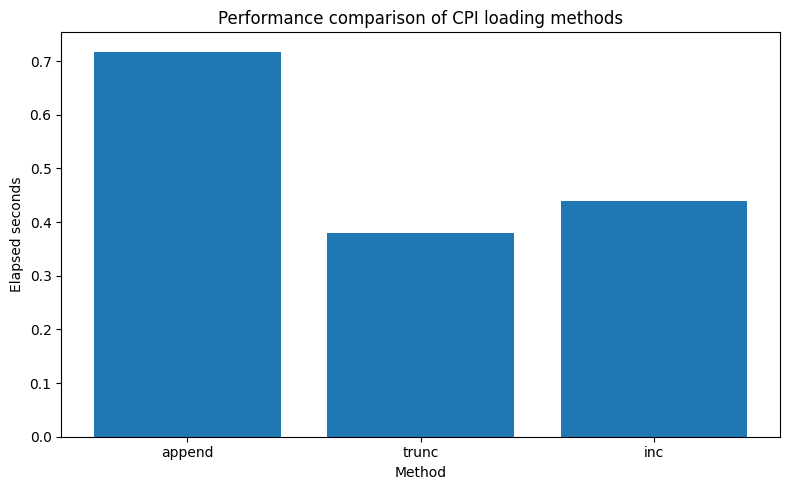

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(timing_df["method"], timing_df["elapsed_seconds"])
plt.xlabel("Method")
plt.ylabel("Elapsed seconds")
plt.title("Performance comparison of CPI loading methods")
plt.tight_layout()
plt.show()


## 8. Inspect final tables after simulation


In [11]:
con = duckdb.connect(str(DB_PATH))

append_latest = con.execute(
    """
    WITH max_date AS (
        SELECT MAX(pull_date) AS pull_date
        FROM cpi_append
    )
    SELECT obs_date, cpi
    FROM cpi_append
    WHERE pull_date = (SELECT pull_date FROM max_date)
    ORDER BY obs_date
    LIMIT 20
    """
).fetchdf()

trunc_preview = con.execute(
    "SELECT obs_date, cpi FROM cpi_trunc ORDER BY obs_date LIMIT 20"
).fetchdf()

inc_preview = con.execute(
    "SELECT obs_date, cpi, last_pull_date FROM cpi_inc ORDER BY obs_date LIMIT 20"
).fetchdf()

append_latest.head(), trunc_preview.head(), inc_preview.head()


(    obs_date   cpi
 0 1947-01-01  21.5
 1 1947-02-01  21.6
 2 1947-03-01  22.0
 3 1947-04-01  22.0
 4 1947-05-01  22.0,
     obs_date   cpi
 0 1947-01-01  21.5
 1 1947-02-01  21.6
 2 1947-03-01  22.0
 3 1947-04-01  22.0
 4 1947-05-01  22.0,
     obs_date   cpi last_pull_date
 0 1947-01-01  21.5     2004-01-01
 1 1947-02-01  21.6     2004-01-01
 2 1947-03-01  22.0     2004-01-01
 3 1947-04-01  22.0     2004-01-01
 4 1947-05-01  22.0     2004-01-01)

## 9. Summary

This notebook demonstrates that:

- all source-data access is centralized in `get_latest_data(pull_date)`
- `append` preserves historical snapshots
- `trunc` keeps only the latest full refresh
- `inc` maintains a current-state table with targeted updates
- the three methods can be compared for both correctness and runtime


## Discussion

### Comparison of Loading Methods

In this lab, three different strategies for loading continuously updated CPI data into a DuckDB database were implemented and compared: append, truncate-and-load, and incremental loading. Each method maintains the dataset in a different way and has different trade-offs in terms of historical tracking, efficiency, and computational cost.

### Append Load

The append method inserts a full snapshot of the latest available CPI data for each pull_date into the table without deleting previous records. As a result, the table grows over time and contains multiple versions of the dataset corresponding to different pull dates. This approach is useful when historical revisions need to be tracked because it preserves all past states of the data. However, the downside is that the table can become very large, since every run inserts a full copy of the dataset. This method also requires safeguards to avoid inserting duplicate records when the same pull date is processed more than once.

### Truncate and Load

The truncate-and-load method deletes all existing rows in the table before inserting the newest snapshot of data. This ensures that the table always contains only the most recent version of the CPI dataset. The implementation is straightforward and guarantees consistency because the table is rebuilt from scratch each time. However, this method can be inefficient for large datasets because it rewrites the entire table on every run, even when only a small number of values have changed.

### Incremental Load

The incremental loading method updates only the rows that have changed and inserts rows that did not previously exist. Each observation date appears only once in the table, and the column last_pull_date records when the row was last updated. Compared with the append and truncate methods, incremental loading is generally more efficient because it avoids rewriting unchanged data. This approach is particularly useful when working with large datasets that receive frequent revisions. However, it is also the most complex method to implement because it requires logic to detect new rows and revisions.

### Consistency Across Methods

To evaluate consistency, the final contents of the tables produced by the three methods were compared after simulating daily runs over a range of dates. The truncate and incremental tables should converge to the same final dataset because both represent the latest available state of the data. The append table, on the other hand, contains historical snapshots and therefore has more rows, but the most recent snapshot in the append table should match the final state of the other two tables.

### Performance Considerations

In terms of performance, the append method tends to increase storage usage over time because it keeps historical snapshots. The truncate method repeatedly rewrites the entire table, which can be inefficient when the dataset grows large. Incremental loading typically provides the best balance between efficiency and data integrity, since only modified rows are processed. For continuously updated datasets such as CPI vintages, incremental loading is often the preferred strategy in production data pipelines.

### Conclusion

The final results show that the trunc and incremental tables converge to the same final dataset, while the append table retains historical snapshots. Incremental loading is generally the most efficient approach for maintaining a continuously updated dataset because it updates only modified rows rather than rewriting the entire table.
